# Copula estimation with fastKDE

```{warning}
This capability is experimental and relatively untested.
```

This notebook demonstrates using `fastKDE` to estimate the copula density of a given dataset.

In [1]:
""" Import libaries """

import fastkde.fastKDE as fastKDE
import fastkde.plot
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
""" Give a simple example of calculating a copula. """

# Generate some data
np.random.seed(0)
n = int(1e6)

# sample from a bivariate normal distribution with zero correlation;
# the copula PDF of this distribution is uniform
xy = np.random.multivariate_normal([0, 0], [[1, 0.0], [0.0, 1]], n)
x = xy[:, 0]
y = xy[:, 1]

# initialize the fastKDE object
kde = fastKDE.fastKDE([x,y])

# calculate the copula
copula = kde.getCopula()

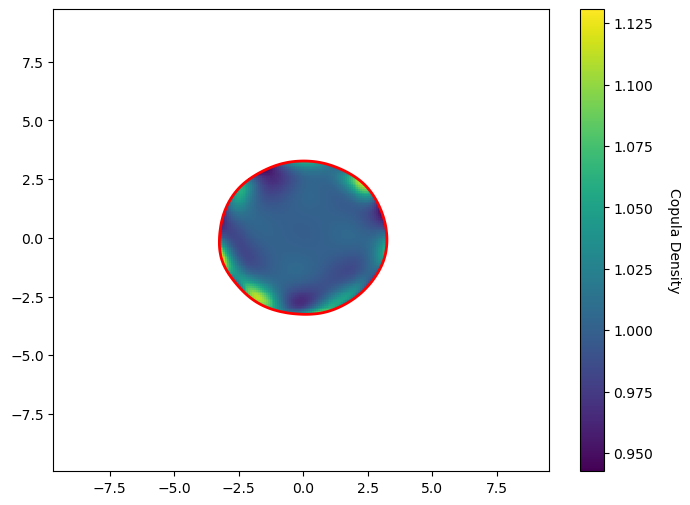

In [3]:
""" Plot the copula """
fig, ax = plt.subplots(figsize=(8, 6))

# get the axis values for the copula
xvals, yvals = kde.axes

# find the 99.5th percentile probability contour of the original data
pval = 1 - 0.995
p_contour_val = fastkde.plot.calculate_probability_contour(
    pdf = kde.pdf[..., np.newaxis],
    axes = [[0]] + kde.axes,
    pvals = pval)

# mask the copula wherever the PDF is less than the 99.95th percentile
mask = kde.pdf < p_contour_val
copula = np.ma.masked_where(mask, copula)

# plot the copula
cplt = ax.pcolormesh(xvals, yvals, copula, cmap='viridis', shading='auto')

# add a colorbar
cbar = plt.colorbar(cplt, ax=ax)
cbar.set_label('Copula Density', rotation=270, labelpad=20)

# plot the 99.5th percentile contour
ax.contour(kde.axes[0], kde.axes[1], kde.pdf, levels=p_contour_val, colors='red', linewidths=2)

plt.show()


```{note}
The copula density is estimated by first estimating the marginal densities of each variable, and then estimating the joint density of the data in the transformed space. The copula density is then obtained by dividing the joint density by the product of the marginal densities.

This leads to large variations in the copula density in regions where the marginal densities are small; this is especially true in regions where data are sparse.  Note in the above that the copula density is masked such that it is only shown in the region where 99.95% of the data lies (as estimated by the `calculate_probability_contour` function). 
```

Within the region where the copula density is shown, it is approximately constant, with values near 1.0.  But there are large variations along the edge.  This illustrates the difficulty in empirically estimating the copula density.
